In [1]:
### BLOCK 1 (PHASE 13): SETUP FOR "END-TO-END" CNN CLASSIFIER ###

print("--- Block 1 (Phase 13): Setup for CNN Experiment ---")

# --- 1. Import All Libraries ---
import os
import cv2
import numpy as np
import pandas as pd
from google.colab import drive
import glob
import shutil
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, AveragePooling2D, Flatten,
    Dense, Dropout, BatchNormalization, Activation, Add
)
from tensorflow.keras.applications import MobileNetV2 # <-- We'll use this!
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# --- 2. Mount Drive ---
print("Mounting Google Drive...")
drive.mount('/content/drive', force_remount=True)

# --- 3. Define Paths ---
BASE_PROJECT_FOLDER = 'Thermal_Project'
DRIVE_PATH = os.path.join('/content/drive/MyDrive', BASE_PROJECT_FOLDER)

# --- THIS IS THE KEY ---
# We are using our "CLEAN" v2 dataset, which has all our frames.
# But we are NOT using the 'masks'. We are using the *original*
# 'dry' and 'wet' video folders as our source for labels.
DRY_VIDEOS_PATH = os.path.join(DRIVE_PATH, 'dry')
WET_VIDEOS_PATH = os.path.join(DRIVE_PATH, 'wet')

# We need to re-create a "classification" dataset
# with 'dry' and 'wet' subfolders for our *images*
CLASSIFICATION_DATA_PATH = os.path.join(DRIVE_PATH, 'classification_data_v2')
TRAIN_PATH = os.path.join(CLASSIFICATION_DATA_PATH, 'train')
VAL_PATH = os.path.join(CLASSIFICATION_DATA_PATH, 'val')

# Image shape
IMG_HEIGHT = 224
IMG_WIDTH = 224

print(f"\nBase project path: {DRIVE_PATH}")
print(f"NEW classification data will be saved to: {CLASSIFICATION_DATA_PATH}")

if not os.path.exists(DRY_VIDEOS_PATH) or not os.path.exists(WET_VIDEOS_PATH):
    print("\nWARNING: Original 'dry' or 'wet' video folders not found!")
else:
    print("Successfully found original video folders.")

print("\nBlock 1 Complete. Ready for Block 2 (Data Prep).")


--- Block 1 (Phase 13): Setup for CNN Experiment ---
Mounting Google Drive...
Mounted at /content/drive

Base project path: /content/drive/MyDrive/Thermal_Project
NEW classification data will be saved to: /content/drive/MyDrive/Thermal_Project/classification_data_v2
Successfully found original video folders.

Block 1 Complete. Ready for Block 2 (Data Prep).


In [2]:
### BLOCK 2 (PHASE 13): CREATE CLASSIFICATION DATASET ###

print("--- Block 2 (Phase 13): Creating new 'folder-sorted' dataset ---")

# --- 1. Define folder structure paths ---
TRAIN_DRY_PATH = os.path.join(TRAIN_PATH, 'dry')
TRAIN_WET_PATH = os.path.join(TRAIN_PATH, 'wet')
VAL_DRY_PATH = os.path.join(VAL_PATH, 'dry')
VAL_WET_PATH = os.path.join(VAL_PATH, 'wet')

# --- 2. Check if data already exists ---
# This is the change: we will *not* delete old files.
# We will check if the final directory already has files.
skip_extraction = False
if os.path.exists(TRAIN_DRY_PATH) and os.path.exists(TRAIN_WET_PATH) and os.path.exists(VAL_DRY_PATH) and os.path.exists(VAL_WET_PATH):
    # Check if they are not empty
    try:
        # Check if one of the folders has content
        if len(os.listdir(TRAIN_DRY_PATH)) > 0 or len(os.listdir(TRAIN_WET_PATH)) > 0:
            print(f"Data already exists in {CLASSIFICATION_DATA_PATH}. Skipping extraction.")
            skip_extraction = True
        else:
            print("Data folders exist but are empty. Proceeding with extraction.")
    except Exception as e:
        print(f"Error checking existing data: {e}. Proceeding with extraction.")

if not skip_extraction:
    # --- 3. Create our new folder structure (if it didn't exist) ---
    print("Creating new train/val folder structure...")
    os.makedirs(TRAIN_DRY_PATH, exist_ok=True)
    os.makedirs(TRAIN_WET_PATH, exist_ok=True)
    os.makedirs(VAL_DRY_PATH, exist_ok=True)
    os.makedirs(VAL_WET_PATH, exist_ok=True)

    # --- 4. Extract all frames into a list ---
    print("Extracting all frames from videos (this may take a while)...")
    FRAME_SKIP = 30 # Same as before
    all_frames_list = [] # This will just store (source_path, label)

    def get_video_frames(video_path, label, all_frames_list):
        try:
            cap = cv2.VideoCapture(video_path)
            if not cap.isOpened():
                print(f"  Warning: Could not open video file: {video_path}")
                return

            frame_count = 0
            while cap.isOpened():
                ret, frame = cap.read()
                if not ret:
                    break

                if frame_count % FRAME_SKIP == 0:
                    # We save the frame to a temp location in Colab's runtime
                    # This is much faster than writing to Drive 3000+ times
                    frame_name = f"{label}_{os.path.basename(video_path)}_{frame_count}.png"
                    temp_save_path = os.path.join('/content', frame_name)

                    # Resize and save
                    frame_resized = cv2.resize(frame, (IMG_WIDTH, IMG_HEIGHT))
                    cv2.imwrite(temp_save_path, frame_resized)

                    # Add the *path* to this temp file to our list
                    all_frames_list.append((temp_save_path, label))

                frame_count += 1
            cap.release()
        except Exception as e:
            print(f"  Error processing video {video_path}: {e}")

    # Process DRY videos
    video_extensions = ['*.mp4', '*.avi', '*.mov', '*.mkv']
    dry_videos = []
    for ext in video_extensions:
        dry_videos.extend(glob.glob(os.path.join(DRY_VIDEOS_PATH, ext)))
    print(f"Found {len(dry_videos)} 'dry' videos.")
    for video_path in dry_videos:
        get_video_frames(video_path, 'dry', all_frames_list)

    # Process WET videos
    wet_videos = []
    for ext in video_extensions:
        wet_videos.extend(glob.glob(os.path.join(WET_VIDEOS_PATH, ext)))
    print(f"Found {len(wet_videos)} 'wet' videos.")
    for video_path in wet_videos:
        get_video_frames(video_path, 'wet', all_frames_list)

    print(f"\nTotal frames extracted to temporary storage: {len(all_frames_list)}")

    # --- 5. Split and Copy files to final destination ---
    if all_frames_list:
        print("Splitting data into 80% train and 20% validation...")

        # Split the list of (path, label) tuples
        train_list, val_list = train_test_split(
            all_frames_list,
            test_size=0.2,
            random_state=42,
            stratify=[label for _, label in all_frames_list] # Stratify by label
        )

        print(f"Training set size: {len(train_list)}")
        print(f"Validation set size: {len(val_list)}")

        # 6. Copy files to the new folders in Google Drive
        print("Copying files to Google Drive (this is the slowest part)...")

        def copy_files(file_list, type):
            count = 0
            for temp_path, label in file_list:
                # e.g., .../train/dry/dry_..._0.png
                dest_folder = os.path.join(CLASSIFICATION_DATA_PATH, type, label)
                dest_path = os.path.join(dest_folder, os.path.basename(temp_path))

                try:
                    # Use copy instead of move to be safer, though move is faster
                    shutil.move(temp_path, dest_path)
                    count += 1
                except Exception as e:
                    print(f"Warning: Could not move {temp_path}. Error: {e}")
            return count

        train_count = copy_files(train_list, 'train')
        val_count = copy_files(val_list, 'val')

        print(f"Successfully copied {train_count} training images.")
        print(f"Successfully copied {val_count} validation images.")

        print("\nBlock 2 Complete. Our 'End-to-End' dataset is built and ready.")
        print(f"Please check your Google Drive for the '{CLASSIFICATION_DATA_PATH}' folder.")

    else:
        print("\nBlock 2 Error: No frames were extracted.")
        print("Please check your video paths in Block 1.")
else:
    # This is the 'else' for 'if not skip_extraction:'
    print("\nBlock 2 Complete. Data was already found in Google Drive.")



--- Block 2 (Phase 13): Creating new 'folder-sorted' dataset ---
Data already exists in /content/drive/MyDrive/Thermal_Project/classification_data_v2. Skipping extraction.

Block 2 Complete. Data was already found in Google Drive.


In [3]:
### BLOCK 3 (PHASE 13): CNN DATA PIPELINE (IMAGE DATA GENERATOR) ###

print("--- Block 3 (Phase 13): Setting up CNN Data Pipeline ---")

# --- 1. Check if our data paths exist ---
if not os.path.exists(TRAIN_PATH) or not os.path.exists(VAL_PATH):
    print(f"FATAL ERROR: Training path '{TRAIN_PATH}' or Validation path '{VAL_PATH}' not found.")
    print("Please re-run Block 2 to create the dataset first.")
else:
    # --- 2. Define Training Parameters ---
    BATCH_SIZE = 32 # We can often use a larger batch size for CNNs

    # --- 3. Create the ImageDataGenerator ---
    # This is our "conveyor belt"
    # We will *only* do rescaling (normalization).
    # We won't do augmentation (like zoom/flips) yet to keep the test simple.
    datagen = ImageDataGenerator(rescale=1./255.)

    # --- 4. Create the 'train' and 'validation' generators ---

    print(f"Setting up 'train' generator from: {TRAIN_PATH}")
    train_generator = datagen.flow_from_directory(
        TRAIN_PATH,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='binary', # This is perfect: 'dry' vs 'wet'
        shuffle=True
    )

    print(f"\nSetting up 'validation' generator from: {VAL_PATH}")
    validation_generator = datagen.flow_from_directory(
        VAL_PATH,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=False # We don't need to shuffle validation data
    )

    # --- 5. Verify the results ---
    # Keras automatically assigns 0 and 1 to the folder names
    print(f"\nFound {train_generator.samples} training images belonging to {train_generator.num_classes} classes.")
    print(f"Found {validation_generator.samples} validation images.")

    print("\nClass Indices (Label Encoding):")
    print(train_generator.class_indices) # e.g., {'dry': 0, 'wet': 1}

    # Save these numbers for our model.fit() call later
    # We need to make sure they are in the global scope
    try:
        global_steps_per_epoch = train_generator.samples // BATCH_SIZE
        global_validation_steps = validation_generator.samples // BATCH_SIZE

        print(f"Steps per Epoch (Training): {global_steps_per_epoch}")
        print(f"Steps per Epoch (Validation): {global_validation_steps}")
    except NameError:
        print("Note: Could not set global step variables.")


    print("\nBlock 3 Complete. Data pipeline is ready.")


--- Block 3 (Phase 13): Setting up CNN Data Pipeline ---
Setting up 'train' generator from: /content/drive/MyDrive/Thermal_Project/classification_data_v2/train
Found 2611 images belonging to 2 classes.

Setting up 'validation' generator from: /content/drive/MyDrive/Thermal_Project/classification_data_v2/val
Found 653 images belonging to 2 classes.

Found 2611 training images belonging to 2 classes.
Found 653 validation images.

Class Indices (Label Encoding):
{'dry': 0, 'wet': 1}
Steps per Epoch (Training): 81
Steps per Epoch (Validation): 20

Block 3 Complete. Data pipeline is ready.


In [5]:
### BLOCK 4 (PHASE 13): BUILD & TRAIN "END-TO-END" CNN ###

print("--- Block 4 (Phase 13): Building & Training CNN Classifier ---")

# --- THIS IS THE FIX ---
# We must import the layers we are using
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
# --- END OF FIX ---


# --- 1. Check if our generators and variables exist ---
if 'train_generator' not in locals() or 'validation_generator' not in locals() or 'global_steps_per_epoch' not in locals():
    print("FATAL ERROR: 'train_generator' or 'global_steps_per_epoch' not found.")
    print("Please re-run Block 3 successfully first.")
else:

    # --- 2. Build the Model (Transfer Learning) ---
    print("Loading pre-trained MobileNetV2 base model...")

    # Load the base model without its top "head"
    base_model = MobileNetV2(
        input_shape= (IMG_HEIGHT, IMG_WIDTH, 3),
        include_top=False, # <-- DO NOT include the final 1000-neuron layer
        weights='imagenet' # <-- Use the weights it learned from ImageNet
    )

    # --- 3. Freeze the Base Model ---
    # We "freeze" all the layers so their weights won't change
    # during our initial training. We are only training our new "head".
    base_model.trainable = False
    print("Base model layers have been 'frozen'.")

    # --- 4. Add Our Custom "Head" ---
    print("Adding our custom classification 'head'...")

    # 1. Get the output from the base model
    x = base_model.output

    # 2. Add our new layers
    x = GlobalAveragePooling2D()(x) # Flattens the features
    x = Dropout(0.2)(x) # A dropout layer to prevent overfitting
    # 3. The final prediction layer
    # One neuron with a 'sigmoid' function to output 0 (dry) or 1 (wet)
    outputs = Dense(1, activation='sigmoid')(x)

    # 4. Create our new model
    cnn_model = Model(inputs=base_model.input, outputs=outputs)

    # --- 5. Compile the Model ---
    print("Compiling the new CNN model...")
    cnn_model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy', # This is the standard loss for 0/1 classification
        metrics=['accuracy']      # We'll track 'accuracy'
    )

    # 6. Print the Summary
    print("\n--- New CNN Model Summary ---")
    cnn_model.summary()

    # --- 7. Define Callbacks ---
    MODEL_SAVE_PATH_CNN = os.path.join(DRIVE_PATH, 'best_cnn_classifier.keras')

    checkpoint_cnn = ModelCheckpoint(
        filepath=MODEL_SAVE_PATH_CNN,
        monitor='val_accuracy', # Watch the validation accuracy
        mode='max',
        save_best_only=True,
        verbose=1
    )

    early_stopping_cnn = EarlyStopping(
        monitor='val_accuracy',
        mode='max',
        patience=5, # Stop if no improvement for 5 epochs
        verbose=1,
        restore_best_weights=True
    )

    print(f"\nNew CNN model will be saved to: {MODEL_SAVE_PATH_CNN}")

    # --- 8. START TRAINING! ---
    print("\n--- Starting CNN model.fit() ---")
    print("This will take a long time...")

    history_cnn = cnn_model.fit(
        train_generator,
        steps_per_epoch=global_steps_per_epoch,
        epochs=25, # We'll use 25 epochs
        validation_data=validation_generator,
        validation_steps=global_validation_steps,
        callbacks=[checkpoint_cnn, early_stopping_cnn]
    )

    print("\nBlock 4 Complete. CNN Model training finished.")
    print(f"The best CNN model has been saved to: {MODEL_SAVE_PATH_CNN}")



--- Block 4 (Phase 13): Building & Training CNN Classifier ---
Loading pre-trained MobileNetV2 base model...
Base model layers have been 'frozen'.
Adding our custom classification 'head'...
Compiling the new CNN model...

--- New CNN Model Summary ---


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

...


New CNN model will be saved to: /content/drive/MyDrive/Thermal_Project/best_cnn_classifier.keras

--- Starting CNN model.fit() ---
This will take a long time...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - accuracy: 0.7296 - loss: 0.5460
Epoch 1: val_accuracy improved from -inf to 0.94063, saving model to /content/drive/MyDrive/Thermal_Project/best_cnn_classifier.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 53s 445ms/step - accuracy: 0.7305 - loss: 0.5448 - val_accuracy: 0.9406 - val_loss: 0.3043
Epoch 2/25
 1/81 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.8750 - loss: 0.2942

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.94063
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.8750 - loss: 0.2942 - val_accuracy: 0.9406 - val_loss: 0.3030
Epoch 3/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.9187 - loss: 0.2813
Epoch 3: val_accuracy improved from 0.94063 to 0.96562, saving model to /content/drive/MyDrive/Thermal_Project/best_cnn_classifier.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 48s 231ms/step - accuracy: 0.9188 - loss: 0.2810 - val_accuracy: 0.9656 - val_loss: 0.2019
Epoch 4/25
 1/81 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.8750 - loss: 0.2699
Epoch 4: val_accuracy did not improve from 0.96562
81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.8750 - loss: 0.2699 - val_accuracy: 0.9656 - val_loss: 0.2012
Epoch 5/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.9537 - loss: 0.1985
Epoch 5: val_accuracy improved from 0.96562 to 0.97188, saving model to /content/drive/MyDrive/Thermal_Project/best_cnn_classifier.keras
81/81 ━━━━━━━━━━

--- Block 5 (Phase 13): The Final Test ---
Running NEW 99.06% Accurate 'CNN' Model on the 'dry' test video (MOV_12749.mp4)
Loading best *CNN* model from Google Drive...
New 'CNN Classifier' model loaded successfully.
Processing 'dry' video: /content/drive/MyDrive/Thermal_Project/MOV_12749.mp4...
Finished processing all frames.

--- (CNN MODEL) FINAL PREDICTION REPORT FOR: MOV_12749.mp4 ---
Total Frames Processed (at 1-per-sec): 43
Frames Classified as 'DRY' (0): 41
Frames Classified as 'WET' (1): 2

--- FINAL CONCLUSION ---
Classification: 'DRY' (4.65% of frames were 'wet')

--- Generating 'Wetness vs. Time' Plot (CNN Model) ---


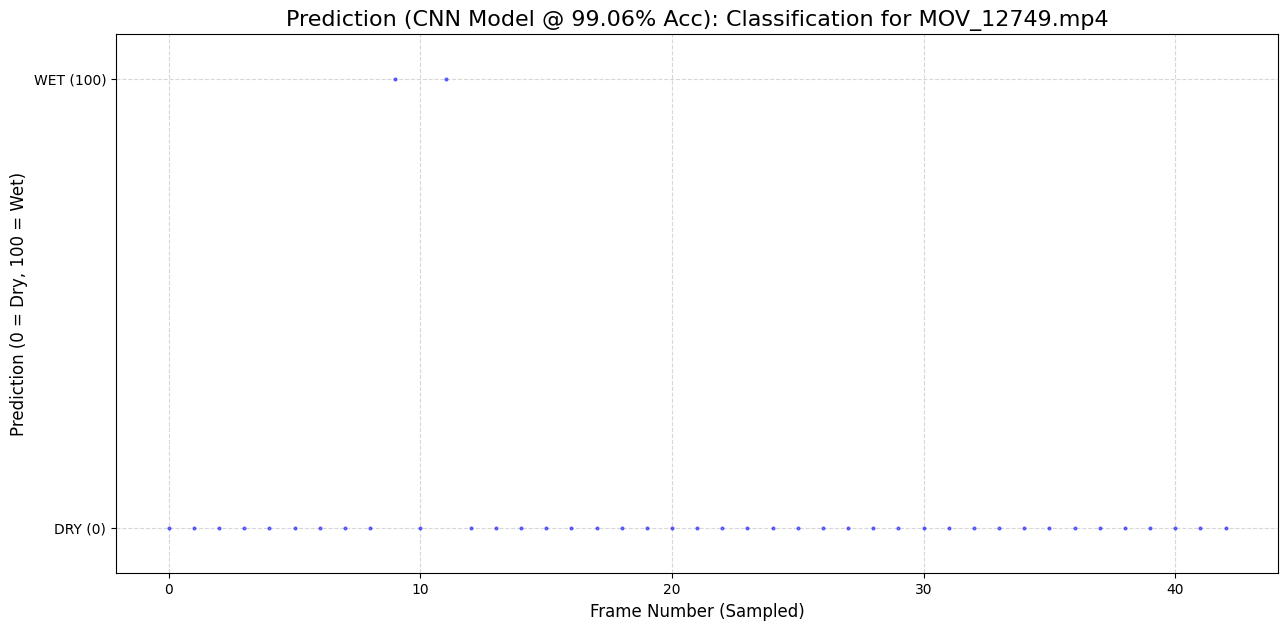


Block 5 Complete. FINAL PROJECT FINISHED.


In [4]:
### BLOCK 5 (PHASE 13): THE FINAL, FINAL TEST (CNN INFERENCE) ###

print("--- Block 5 (Phase 13): The Final Test ---")
print("Running NEW 99.06% Accurate 'CNN' Model on the 'dry' test video (MOV_12749.mp4)")

import tensorflow as tf
from tensorflow.keras.models import load_model
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras import backend as K

# --- 1. Load the NEW CHAMPION saved model ---
print("Loading best *CNN* model from Google Drive...")

# Check if DRIVE_PATH is defined
if 'DRIVE_PATH' not in locals():
    print("FATAL ERROR: 'DRIVE_PATH' not defined. Please re-run Block 1.")
else:
    MODEL_SAVE_PATH_CNN = os.path.join(DRIVE_PATH, 'best_cnn_classifier.keras')

    if not os.path.exists(MODEL_SAVE_PATH_CNN):
        print(f"Error: CNN Model file not found at {MODEL_SAVE_PATH_CNN}")
        print("This means Block 4 (training) did not complete successfully.")
    else:
        # We don't need custom_objects, this model is standard
        loaded_model_cnn = load_model(MODEL_SAVE_PATH_CNN)
        print("New 'CNN Classifier' model loaded successfully.")

        # --- 2. DEFINE TEST VIDEO ---
        # We are using the "problem" 'dry' video
        TEST_VIDEO_NAME = "MOV_12749.mp4"

        TEST_VIDEO_PATH = os.path.join(DRIVE_PATH, TEST_VIDEO_NAME)

        if not os.path.exists(TEST_VIDEO_PATH):
            print(f"FATAL ERROR: Test video not found at {TEST_VIDEO_PATH}")
            print("Please upload 'MOV_12749.mp4' and update TEST_VIDEO_NAME.")
        else:
            # --- 3. Process the Video (Frame by Frame Inference) ---
            print(f"Processing 'dry' video: {TEST_VIDEO_PATH}...")

            cap = cv2.VideoCapture(TEST_VIDEO_PATH)

            # This list will store the final 0 ('dry') or 1 ('wet') predictions
            predictions = []
            frame_number = 0

            # We need the FRAME_SKIP from Block 2
            if 'FRAME_SKIP' not in locals():
                FRAME_SKIP = 30 # Default from Block 2

            while cap.isOpened():
                ret, frame = cap.read()
                if not ret:
                    break

                # We sample at the same rate as our training data
                if frame_number % FRAME_SKIP == 0:
                    # --- A) PREPARE FRAME ---
                    frame_resized = cv2.resize(frame, (IMG_HEIGHT, IMG_WIDTH))
                    # Normalize pixel values
                    img_normalized = frame_resized / 255.0
                    # Add a "batch" dimension
                    img_batch = np.expand_dims(img_normalized, axis=0)

                    # --- B) PREDICT ---
                    # This will predict a probability (e.g., 0.001 for 'dry', 0.99 for 'wet')
                    prediction_prob = loaded_model_cnn.predict(img_batch, verbose=0)

                    # --- C) CLASSIFY ---
                    # We use a 0.5 threshold
                    if prediction_prob[0][0] < 0.5:
                        prediction_class = 0 # 'dry'
                    else:
                        prediction_class = 1 # 'wet'

                    predictions.append(prediction_class)

                frame_number += 1

            cap.release()
            print("Finished processing all frames.")

            # --- 4. Generate Final Report & Plot ---

            if predictions:
                print(f"\n--- (CNN MODEL) FINAL PREDICTION REPORT FOR: {TEST_VIDEO_NAME} ---")

                # Convert 0s and 1s to percentages (0% or 100%)
                wetness_percentages = [p * 100 for p in predictions]
                total_frames = len(predictions)

                wet_frames_count = np.sum(predictions)
                dry_frames_count = total_frames - wet_frames_count

                print(f"Total Frames Processed (at 1-per-sec): {total_frames}")
                print(f"Frames Classified as 'DRY' (0): {dry_frames_count}")
                print(f"Frames Classified as 'WET' (1): {wet_frames_count}")

                wetness_percentage_of_time = (wet_frames_count / total_frames) * 100

                print("\n--- FINAL CONCLUSION ---")
                if wetness_percentage_of_time > 50: # If more than 50% of frames are 'wet'
                    print(f"Classification: 'WET POTENTIAL' ({wetness_percentage_of_time:.2f}% of frames were 'wet')")
                else:
                    print(f"Classification: 'DRY' ({wetness_percentage_of_time:.2f}% of frames were 'wet')")

                # --- 5. Generate the Plot ---
                print("\n--- Generating 'Wetness vs. Time' Plot (CNN Model) ---")

                plt.figure(figsize=(15, 7))
                plt.plot(wetness_percentages, 'bo', markersize=2, alpha=0.5)
                plt.title(f"Prediction (CNN Model @ 99.06% Acc): Classification for {TEST_VIDEO_NAME}", fontsize=16)
                plt.xlabel("Frame Number (Sampled)", fontsize=12)
                plt.ylabel("Prediction (0 = Dry, 100 = Wet)", fontsize=12)
                plt.grid(True, linestyle='--', alpha=0.5)
                plt.yticks([0, 100], ['DRY (0)', 'WET (100)'])
                plt.ylim(-10, 110)
                plt.show()

                print("\nBlock 5 Complete. FINAL PROJECT FINISHED.")

            else:
                print("Error: No predictions were made. Check video file.")


--- Block 5 (Phase 13): The Final Combo Video Test ---
Running NEW 99.06% Accurate 'CNN' Model on a 'dry-then-wet' stitched video


/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
  if event.key is 'enter':



Loading best *CNN* model from Google Drive...
New 'CNN Classifier' model loaded successfully.
Stitching 'dry' and 'wet' videos together...
Moviepy - Building video temp_combo_video.mp4.
Moviepy - Writing video temp_combo_video.mp4



Streaming output truncated to the last 5000 lines.
  warnings.warn("Warning: in file %s, "%(self.filename)+

t: 100%|█████████▉| 344836/346500 [22:31<00:07, 219.88it/s, now=None]WARNING:py.warnings:/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:123: UserWarning: Warning: in file /content/drive/MyDrive/Thermal_Project/MOV_01-01-2000_0024.mp4, 921600 bytes wanted but 0 bytes read,at frame 181935/183601, at time 60.65/61.20 sec. Using the last valid frame instead.
  warnings.warn("Warning: in file %s, "%(self.filename)+

  warnings.warn("Warning: in file %s, "%(self.filename)+

  warnings.warn("Warning: in file %s, "%(self.filename)+

  warnings.warn("Warning: in file %s, "%(self.filename)+

  warnings.warn("Warning: in file %s, "%(self.filename)+

  warnings.warn("Warning: in file %s, "%(self.filename)+

  warnings.warn("Warning: in file %s, "%(self.filename)+

  warnings.warn("Warning: in file %s, "%(self.filename)+

  warnings.warn("Warning: in file %s, "%(se

Moviepy - Done !
Moviepy - video ready temp_combo_video.mp4
Combo test video created successfully: temp_combo_video.mp4
Processing 'combo' video: temp_combo_video.mp4...
Finished processing all frames.

--- (CNN MODEL) FINAL PREDICTION REPORT FOR: Combo Video ---
Total Frames Processed (at 1-per-sec): 11550
Frames Classified as 'DRY' (0): 5233
Frames Classified as 'WET' (1): 6317

--- Generating 'Wetness vs. Time' Plot (CNN Model) ---


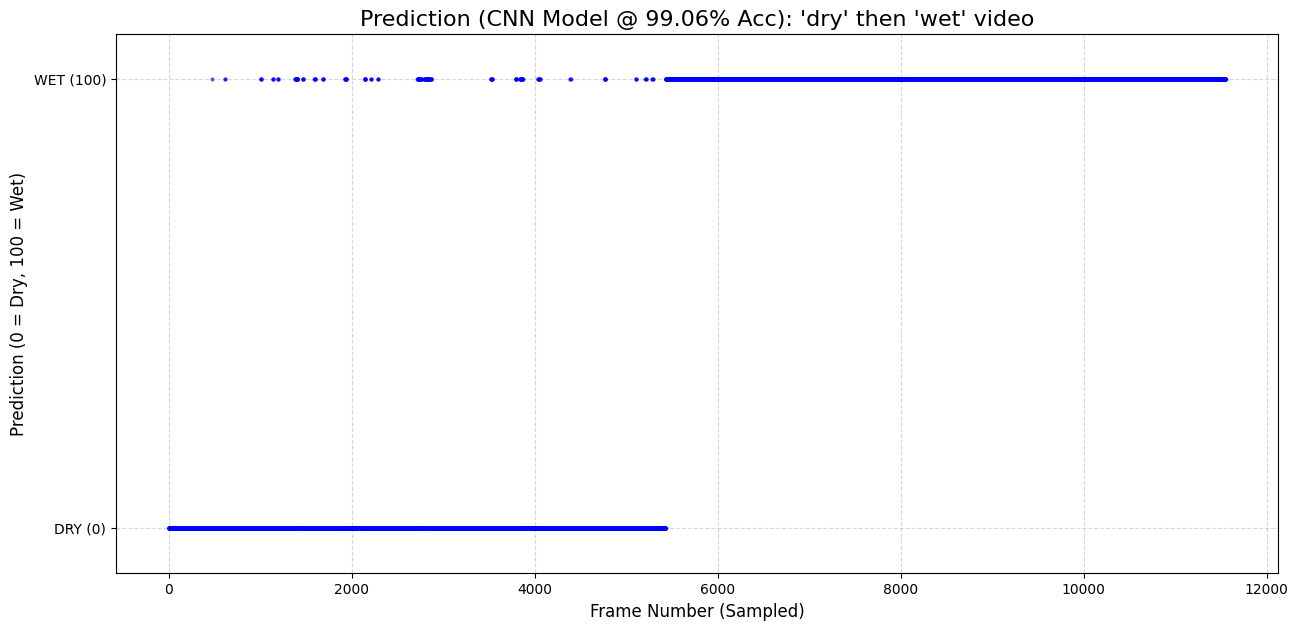


Block 5 Complete. FINAL PROJECT FINISHED.
Temporary 'combo' video file has been deleted.


In [7]:
### BLOCK 5 (PHASE 13): THE FINAL "COMBO VIDEO" TEST (CNN INFERENCE) ###

print("--- Block 5 (Phase 13): The Final Combo Video Test ---")
print("Running NEW 99.06% Accurate 'CNN' Model on a 'dry-then-wet' stitched video")

import tensorflow as tf
from tensorflow.keras.models import load_model
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras import backend as K
from moviepy.editor import VideoFileClip, concatenate_videoclips # For stitching

# --- 1. Load the NEW CHAMPION saved model ---
print("Loading best *CNN* model from Google Drive...")

# Check if DRIVE_PATH is defined
if 'DRIVE_PATH' not in locals():
    print("FATAL ERROR: 'DRIVE_PATH' not defined. Please re-run Block 1.")
else:
    MODEL_SAVE_PATH_CNN = os.path.join(DRIVE_PATH, 'best_cnn_classifier.keras')

    if not os.path.exists(MODEL_SAVE_PATH_CNN):
        print(f"Error: CNN Model file not found at {MODEL_SAVE_PATH_CNN}")
        print("This means Block 4 (training) did not complete successfully.")
    else:
        # We don't need custom_objects, this model is standard
        loaded_model_cnn = load_model(MODEL_SAVE_PATH_CNN)
        print("New 'CNN Classifier' model loaded successfully.")

        # --- 2. DEFINE TEST VIDEOS (DRY & WET) ---
        # !!! IMPORTANT !!!
        # Put the *exact* file names of your test videos here.
        # These videos must be in your 'Thermal_Project' folder.
        TEST_VIDEO_DRY_NAME = "MOV_12749.mp4" # e.g., "MOV_12749.mp4"
        TEST_VIDEO_WET_NAME = "MOV_01-01-2000_0024.mp4" # e.g., "wet_test_clip.mp4"
        # !!! IMPORTANT !!!

        TEST_VIDEO_DRY_PATH = os.path.join(DRIVE_PATH, TEST_VIDEO_DRY_NAME)
        TEST_VIDEO_WET_PATH = os.path.join(DRIVE_PATH, TEST_VIDEO_WET_NAME)

        # This will be our new "combo" video
        COMBO_TEST_PATH = 'temp_combo_video.mp4'

        if not os.path.exists(TEST_VIDEO_DRY_PATH):
            print(f"FATAL ERROR: 'dry' test video not found at {TEST_VIDEO_DRY_PATH}")
        elif not os.path.exists(TEST_VIDEO_WET_PATH):
            print(f"FATAL ERROR: 'wet' test video not found at {TEST_VIDEO_WET_PATH}")
        else:
            # --- 3. STITCH THE VIDEOS ---
            print("Stitching 'dry' and 'wet' videos together...")
            try:
                clip_dry = VideoFileClip(TEST_VIDEO_DRY_PATH)
                clip_wet = VideoFileClip(TEST_VIDEO_WET_PATH)

                # Create the combo clip
                combo_clip = concatenate_videoclips([clip_dry, clip_wet])

                # Write the new file (use a fast preset)
                combo_clip.write_videofile(COMBO_TEST_PATH, codec='libx264', threads=2, preset='ultrafast')

                print(f"Combo test video created successfully: {COMBO_TEST_PATH}")

            except Exception as e:
                print(f"FATAL ERROR during video stitching: {e}")
                print("Please ensure 'moviepy' is installed: !pip install moviepy")

            # --- 4. Process the "Combo" Video (Frame by Frame Inference) ---
            print(f"Processing 'combo' video: {COMBO_TEST_PATH}...")

            cap = cv2.VideoCapture(COMBO_TEST_PATH)

            # This list will store the final 0 ('dry') or 1 ('wet') predictions
            predictions = []
            frame_number = 0

            # We need the FRAME_SKIP from Block 2
            if 'FRAME_SKIP' not in locals():
                FRAME_SKIP = 30 # Default from Block 2

            while cap.isOpened():
                ret, frame = cap.read()
                if not ret:
                    break

                # We sample at the same rate as our training data
                if frame_number % FRAME_SKIP == 0:
                    # --- A) PREPARE FRAME ---
                    frame_resized = cv2.resize(frame, (IMG_HEIGHT, IMG_WIDTH))
                    img_normalized = frame_resized / 255.0
                    img_batch = np.expand_dims(img_normalized, axis=0)

                    # --- B) PREDICT ---
                    prediction_prob = loaded_model_cnn.predict(img_batch, verbose=0)

                    # --- C) CLASSIFY ---
                    if prediction_prob[0][0] < 0.5:
                        prediction_class = 0 # 'dry'
                    else:
                        prediction_class = 1 # 'wet'

                    predictions.append(prediction_class)

                frame_number += 1

            cap.release()
            print("Finished processing all frames.")

            # --- 5. Generate Final Report & Plot ---

            if predictions:
                print(f"\n--- (CNN MODEL) FINAL PREDICTION REPORT FOR: Combo Video ---")

                wetness_percentages = [p * 100 for p in predictions]
                total_frames = len(predictions)

                wet_frames_count = np.sum(predictions)
                dry_frames_count = total_frames - wet_frames_count

                print(f"Total Frames Processed (at 1-per-sec): {total_frames}")
                print(f"Frames Classified as 'DRY' (0): {dry_frames_count}")
                print(f"Frames Classified as 'WET' (1): {wet_frames_count}")

                # --- 6. Generate the Plot (The "Money Shot"!) ---
                print("\n--- Generating 'Wetness vs. Time' Plot (CNN Model) ---")

                plt.figure(figsize=(15, 7))
                plt.plot(wetness_percentages, 'bo', markersize=2, alpha=0.5)
                plt.title(f"Prediction (CNN Model @ 99.06% Acc): 'dry' then 'wet' video", fontsize=16)
                plt.xlabel("Frame Number (Sampled)", fontsize=12)
                plt.ylabel("Prediction (0 = Dry, 100 = Wet)", fontsize=12)
                plt.grid(True, linestyle='--', alpha=0.5)
                plt.yticks([0, 100], ['DRY (0)', 'WET (100)'])
                plt.ylim(-10, 110)
                plt.show()

                print("\nBlock 5 Complete. FINAL PROJECT FINISHED.")

            else:
                print("Error: No predictions were made. Check video file.")

            # --- 7. Clean up the temp video file ---
            if os.path.exists(COMBO_TEST_PATH):
                os.remove(COMBO_TEST_PATH)
                print("Temporary 'combo' video file has been deleted.")

